In [1]:
import os
import cv2
import numpy as np
import pandas as pd

from insightface.app import FaceAnalysis

In [3]:
from pathlib import Path

# Keep InsightFace model cache inside this project folder.
ROOT_DIR = str((Path.cwd() / ".insightface").resolve())

# If want GPU, set ctx_id = 0 and use CUDAExecutionProvider.
providers = ["CPUExecutionProvider"]
ctx_id = -1

model_l = FaceAnalysis(
    name="buffalo_l",
    root=ROOT_DIR,
    providers=providers,
    )

model_l.prepare(ctx_id=ctx_id, det_size=(640, 640), det_thresh=0.70)

print(f"Providers: {providers}")
print(f"ctx_id: {ctx_id} (CPU)")
print(f"Model root: {ROOT_DIR}")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\chans\Documents\Sopheak\PersonalProject\fullstack\face-regcon-attendance\face_recognition_attendance_system\my-own-experiement\.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\chans\Documents\Sopheak\PersonalProject\fullstack\face-regcon-attendance\face_recognition_attendance_system\my-own-experiement\.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\chans\Documents\Sopheak\PersonalProject\fullstack\face-regcon-attendance\face_recognition_attendance_system\my-own-experiement\.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecution

# Choose Data Source, Test Image, and Threshold
Use `reference_source = "prototype"` for one vector per person, or `"enrollment"` for all image vectors. `COSINE_THRESHOLD` is used to decide known vs `Unknown`.

In [8]:
from pathlib import Path


BASE_DIR = Path.cwd()
ARTIFACTS_DIR = BASE_DIR / "artifacts"

if not ARTIFACTS_DIR.exists():
    raise FileNotFoundError("artifacts folder not found. Open/run this notebook from my-own-experiement.")

# Pick reference source
reference_source = "prototype"

# Threshold for known
COSINE_THRESHOLD = 0.60

# Pick test image (start with image1)
test_data1 = "my-own-experiement/data/holland/Image_3.jpg"

candidate_paths = [
    Path(test_data1),
    Path("data/holland/Image_3.jpg"),
    BASE_DIR / test_data1,
    BASE_DIR / "data" / "holland" / "Image_3.jpg",
]
test_image_path = next((p.resolve() for p in candidate_paths if p.exists()), Path(test_data1))

enroll_csv = ARTIFACTS_DIR / "enrollment_embeddings.csv"
proto_csv = ARTIFACTS_DIR / "person_prototypes.csv"

def get_embedding_columns(df):
    cols = [c for c in df.columns if c.startswith("e")]
    return sorted(cols, key=lambda c: int(c[1:]))

if reference_source == "prototype":
    ref_df = pd.read_csv(proto_csv)
else:
    ref_df = pd.read_csv(enroll_csv)

emb_cols = get_embedding_columns(ref_df)
X = ref_df[emb_cols].to_numpy(dtype=np.float32)

# Normalize reference vectors
X_norm = np.linalg.norm(X, axis=1, keepdims=True)
X = X / np.clip(X_norm, 1e-12, None)

labels = ref_df["person"].astype(str).to_numpy()

print(f"BASE_DIR: {BASE_DIR}")
print(f"Reference source: {reference_source}")
print(f"Known/Unknown threshold: {COSINE_THRESHOLD}")
print(f"Reference shape X: {X.shape}")
print(f"Test image: {test_image_path}")
print(f"Test image exists: {test_image_path.exists()}")

BASE_DIR: c:\Users\chans\Documents\Sopheak\PersonalProject\fullstack\face-regcon-attendance\face_recognition_attendance_system\my-own-experiement
Reference source: prototype
Known/Unknown threshold: 0.6
Reference shape X: (7, 512)
Test image: C:\Users\chans\Documents\Sopheak\PersonalProject\fullstack\face-regcon-attendance\face_recognition_attendance_system\my-own-experiement\data\holland\Image_3.jpg
Test image exists: True


# Extract Test Embedding and Compute Distances
This cell extracts the test feature vector, computes Euclidean/Manhattan/Cosine scores, then applies `COSINE_THRESHOLD` to output either a person name or `Unknown`.

In [9]:
from sklearn.metrics import pairwise

img = cv2.imread(str(test_image_path))
if img is None:
    raise ValueError(f"Cannot read test image: {test_image_path}")

faces = model_l.get(img, max_num=1)
if len(faces) == 0:
    raise ValueError("No face detected in test image.")

test_embedding = faces[0]["embedding"].astype(np.float32)
test_embedding = test_embedding / max(np.linalg.norm(test_embedding), 1e-12)

y = test_embedding.reshape(1, -1)  # 1 x 512 from 512
print("y shape:", y.shape)

# Euclidean distances
euclidean_distance = pairwise.euclidean_distances(X, y)

# Manhattan distances
manhattan_distance = pairwise.manhattan_distances(X, y)

# Cosine similarity
cosine_similarity = pairwise.cosine_similarity(X, y)

distance_df = pd.DataFrame({
    "person": labels,
    "euclidean": euclidean_distance.ravel(),
    "manhattan": manhattan_distance.ravel(),
    "cosine": cosine_similarity.ravel(),
})

distance_df["above_threshold"] = distance_df["cosine"] >= COSINE_THRESHOLD

# Keep closest-by-cosine at top
distance_df = distance_df.sort_values("cosine", ascending=False).reset_index(drop=True)
display(distance_df.head(10))

best = distance_df.iloc[0]
predicted_label = best["person"] if float(best["cosine"]) >= COSINE_THRESHOLD else "Unknown"

print(f"Threshold: {COSINE_THRESHOLD:.2f}")
print(f"Best cosine: {best['cosine']:.4f}")
print(f"Prediction: {predicted_label}")

c:\Users\chans\Documents\Sopheak\PersonalProject\fullstack\face-regcon-attendance\face_recognition_attendance_system\my-own-experiement\env\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


y shape: (1, 512)


,person,euclidean,manhattan,cosine,above_threshold
0,holland,0.635289,11.626041,0.798204,True
1,sopheak,1.311451,23.702434,0.140047,False
2,Sanna,1.378186,24.641793,0.050302,False
3,vit,1.425541,25.574819,-0.016085,False
4,Rothana,1.427204,25.381290,-0.018456,False
5,roth,1.435504,25.952663,-0.030336,False
6,vannet,1.453850,25.847088,-0.056840,False


Threshold: 0.60
Best cosine: 0.7982
Prediction: holland


## Step 3: 2D Visualization (PCA)
Project reference vectors and the test vector into 2D, so you can visually see which identity cluster the test point is closest to.

C:\Users\chans\AppData\Local\Temp\ipykernel_17808\3167873345.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_people))


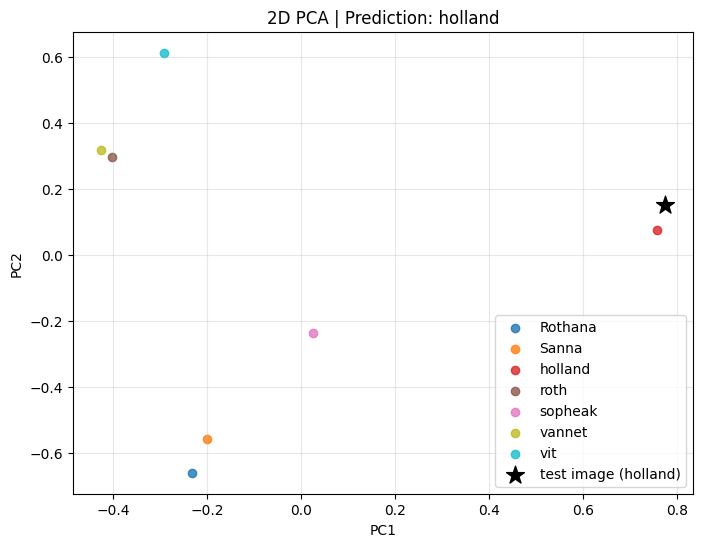

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

all_vectors = np.vstack([X, y])  # reference + test
pca2 = PCA(n_components=2, random_state=42)
xy2 = pca2.fit_transform(all_vectors)

ref_2d = xy2[:-1]
test_2d = xy2[-1]

unique_people = sorted(pd.unique(labels))
cmap = plt.cm.get_cmap("tab10", len(unique_people))
color_map = {p: cmap(i) for i, p in enumerate(unique_people)}

test_color = "black" if predicted_label != "Unknown" else "red"
test_name = f"test image ({predicted_label})"

plt.figure(figsize=(8, 6))
for p in unique_people:
    mask = labels == p
    plt.scatter(ref_2d[mask, 0], ref_2d[mask, 1], s=36, alpha=0.8, color=color_map[p], label=p)

plt.scatter(test_2d[0], test_2d[1], s=180, marker="*", color=test_color, label=test_name)
plt.title(f"2D PCA | Prediction: {predicted_label}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

## Step 4: 3D Visualization (PCA)
Same idea as 2D, but with 3 principal components to see separation in a richer view.

C:\Users\chans\AppData\Local\Temp\ipykernel_17808\1405672678.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_people))


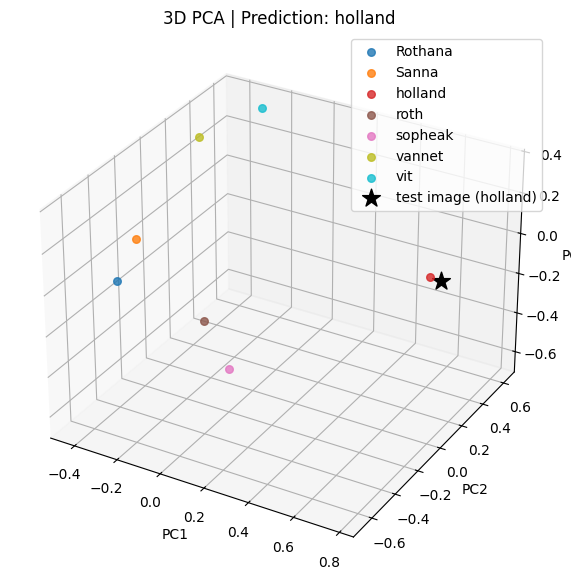

In [11]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

all_vectors = np.vstack([X, y])
pca3 = PCA(n_components=3, random_state=42)
xyz3 = pca3.fit_transform(all_vectors)

ref_3d = xyz3[:-1]
test_3d = xyz3[-1]

unique_people = sorted(pd.unique(labels))
cmap = plt.cm.get_cmap("tab10", len(unique_people))
color_map = {p: cmap(i) for i, p in enumerate(unique_people)}

test_color = "black" if predicted_label != "Unknown" else "red"
test_name = f"test image ({predicted_label})"

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for p in unique_people:
    mask = labels == p
    ax.scatter(
        ref_3d[mask, 0],
        ref_3d[mask, 1],
        ref_3d[mask, 2],
        s=30,
        alpha=0.8,
        color=color_map[p],
        label=p,
    )

ax.scatter(
    test_3d[0], test_3d[1], test_3d[2],
    s=180, marker="*", color=test_color, label=test_name
    )

ax.set_title(f"3D PCA | Prediction: {predicted_label}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(loc="best")
plt.show()